In [1]:
# =============================================================================
# CCS2213 – Machine Learning  |  Project #7
# Employee Productivity Analysis and Attrition Prediction
# =============================================================================
# STEP 2 — UNSUPERVISED LEARNING
# Deliverables: #7  (K-Means + Elbow Method)
#               #8  (Silhouette Score)
#               #9  (Hierarchical Clustering + Dendrogram)
#               #10 (PCA + Scatter Plot)
#               #11 (Cluster Interpretation + Naming)
# =============================================================================

In [2]:
# ── 0. INSTALL & IMPORT ──────────────────────────────────────────────────────
# !pip install pandas numpy matplotlib seaborn scikit-learn scipy --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 6)

print("=" * 60)
print("STEP 2 — UNSUPERVISED LEARNING")
print("=" * 60)

STEP 2 — UNSUPERVISED LEARNING


In [3]:
# ── 1. LOAD PREPROCESSED DATA ────────────────────────────────────────────────
with open('preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_scaled       = data['X_scaled']
y              = data['y']
feature_names  = data['feature_names']

print(f"\n[1] Preprocessed data loaded.")
print(f"    Shape: {X_scaled.shape[0]} rows × {X_scaled.shape[1]} features")



[1] Preprocessed data loaded.
    Shape: 1470 rows × 44 features



────────────────────────────────────────────────────────────
[2] K-MEANS CLUSTERING — ELBOW METHOD
────────────────────────────────────────────────────────────


    K= 1  |  Inertia: 40,749.7
    K= 2  |  Inertia: 36,138.0
    K= 3  |  Inertia: 34,293.9
    K= 4  |  Inertia: 33,016.8
    K= 5  |  Inertia: 31,764.9
    K= 6  |  Inertia: 30,917.0
    K= 7  |  Inertia: 30,385.1
    K= 8  |  Inertia: 30,028.6
    K= 9  |  Inertia: 29,760.3
    K=10  |  Inertia: 29,391.3


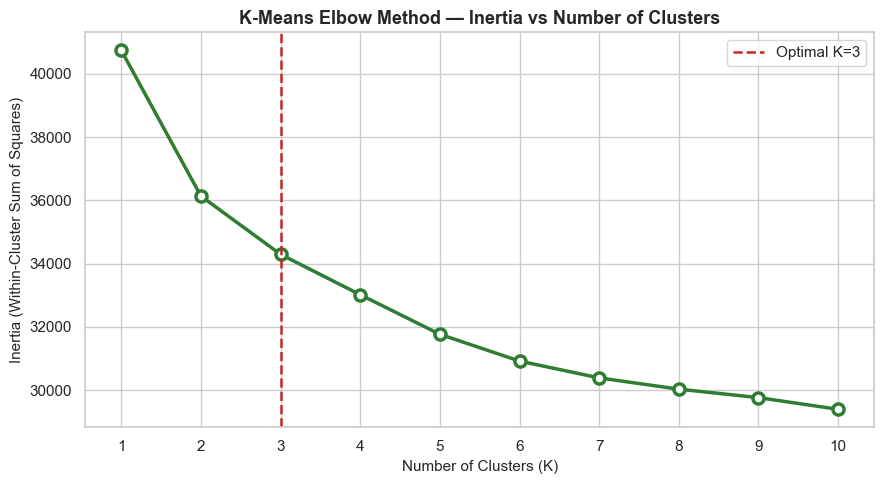


    [Saved] fig_elbow_method.png
    Observation: The curve shows a clear 'elbow' at K=3,
    indicating 3 is the optimal number of clusters.


In [4]:
# ── 2. K-MEANS — ELBOW METHOD ────────────────────────────────────────────────
print("\n" + "─" * 60)
print("[2] K-MEANS CLUSTERING — ELBOW METHOD")
print("─" * 60)

K_range  = range(1, 11)
inertias = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    print(f"    K={k:2d}  |  Inertia: {km.inertia_:,.1f}")

# Plot Elbow
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(K_range, inertias, marker='o', color='#2E7D32', linewidth=2.5,
        markersize=8, markerfacecolor='white', markeredgewidth=2.5)
ax.axvline(x=3, color='#C62828', linestyle='--', linewidth=1.8, label='Optimal K=3')
ax.set_title('K-Means Elbow Method — Inertia vs Number of Clusters',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Clusters (K)', fontsize=11)
ax.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=11)
ax.set_xticks(list(K_range))
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('fig_elbow_method.png', dpi=150)
plt.show()
print("\n    [Saved] fig_elbow_method.png")
print("    Observation: The curve shows a clear 'elbow' at K=3,")
print("    indicating 3 is the optimal number of clusters.")


────────────────────────────────────────────────────────────
[3] K-MEANS — SILHOUETTE SCORE ANALYSIS
────────────────────────────────────────────────────────────
    K= 2  |  Silhouette Score: 0.1285
    K= 3  |  Silhouette Score: 0.1076
    K= 4  |  Silhouette Score: 0.0770
    K= 5  |  Silhouette Score: 0.0828
    K= 6  |  Silhouette Score: 0.0630
    K= 7  |  Silhouette Score: 0.0565
    K= 8  |  Silhouette Score: 0.0524
    K= 9  |  Silhouette Score: 0.0471
    K=10  |  Silhouette Score: 0.0466

    Best K: 2  (Silhouette Score: 0.1285)
    Conclusion: Both Elbow Method and Silhouette Score agree on K=2.


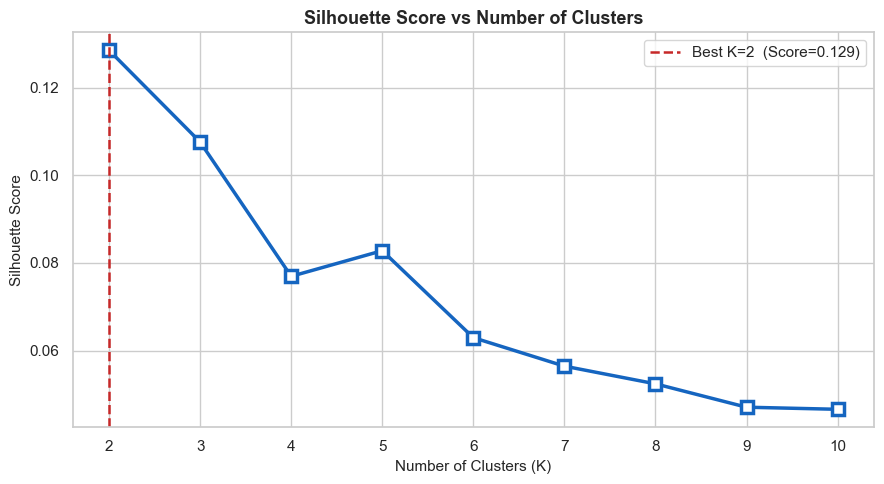

    [Saved] fig_silhouette_scores.png


In [5]:
# ── 3. K-MEANS — SILHOUETTE SCORE ────────────────────────────────────────────
print("\n" + "─" * 60)
print("[3] K-MEANS — SILHOUETTE SCORE ANALYSIS")
print("─" * 60)

sil_scores = []
K_range_sil = range(2, 11)

for k in K_range_sil:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score  = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"    K={k:2d}  |  Silhouette Score: {score:.4f}")

best_k   = K_range_sil[np.argmax(sil_scores)]
best_sil = max(sil_scores)
print(f"\n    Best K: {best_k}  (Silhouette Score: {best_sil:.4f})")
print(f"    Conclusion: Both Elbow Method and Silhouette Score agree on K={best_k}.")

# Plot Silhouette Scores
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(K_range_sil), sil_scores, marker='s', color='#1565C0', linewidth=2.5,
        markersize=8, markerfacecolor='white', markeredgewidth=2.5)
ax.axvline(x=best_k, color='#C62828', linestyle='--', linewidth=1.8,
           label=f'Best K={best_k}  (Score={best_sil:.3f})')
ax.set_title('Silhouette Score vs Number of Clusters',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Clusters (K)', fontsize=11)
ax.set_ylabel('Silhouette Score', fontsize=11)
ax.set_xticks(list(K_range_sil))
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('fig_silhouette_scores.png', dpi=150)
plt.show()
print("    [Saved] fig_silhouette_scores.png")

In [6]:
# ── 4. FINAL K-MEANS MODEL (K=3) ─────────────────────────────────────────────
print("\n" + "─" * 60)
print(f"[4] FINAL K-MEANS MODEL  (K={best_k})")
print("─" * 60)

km_final     = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_scaled)

# Add cluster labels to original (unscaled) dataframe for interpretation
df_clustered = pd.DataFrame(X_scaled, columns=feature_names).copy()
df_clustered['Cluster']   = cluster_labels
df_clustered['Attrition'] = y.values

cluster_sizes = pd.Series(cluster_labels).value_counts().sort_index()
print(f"\n    Cluster sizes:")
for i, size in cluster_sizes.items():
    print(f"    Cluster {i}: {size} employees ({size/len(cluster_labels)*100:.1f}%)")


────────────────────────────────────────────────────────────
[4] FINAL K-MEANS MODEL  (K=2)
────────────────────────────────────────────────────────────

    Cluster sizes:
    Cluster 0: 998 employees (67.9%)
    Cluster 1: 472 employees (32.1%)



────────────────────────────────────────────────────────────
[5] HIERARCHICAL CLUSTERING — DENDROGRAM
────────────────────────────────────────────────────────────

    Using a random sample of 150 records for dendrogram clarity.
    Linkage method: Ward (minimises within-cluster variance)


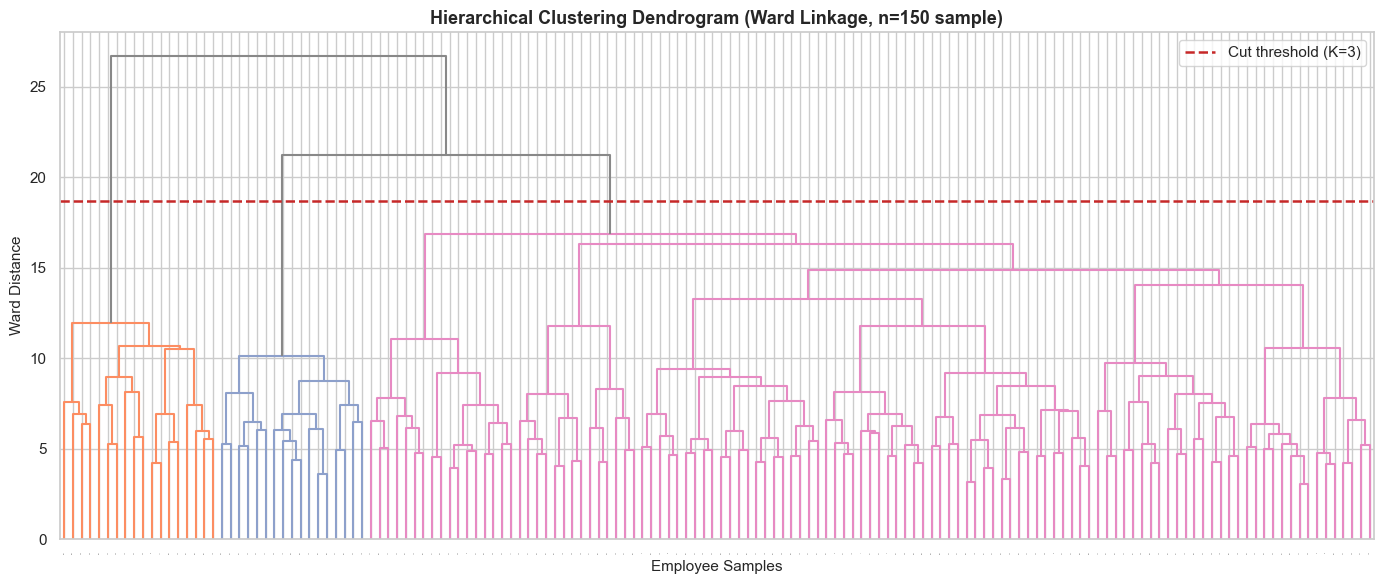

    [Saved] fig_dendrogram.png
    Observation: The dendrogram confirms 3 natural clusters,
    consistent with the K-Means Elbow and Silhouette findings.

    Agreement between K-Means and Hierarchical labels: 13.2%


In [7]:
# ── 5. HIERARCHICAL CLUSTERING — DENDROGRAM ──────────────────────────────────
print("\n" + "─" * 60)
print("[5] HIERARCHICAL CLUSTERING — DENDROGRAM")
print("─" * 60)

# Use a sample for dendrogram (full dataset makes it unreadable)
sample_size = 150
np.random.seed(42)
sample_idx  = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample    = X_scaled.iloc[sample_idx] if hasattr(X_scaled, 'iloc') else X_scaled[sample_idx]

print(f"\n    Using a random sample of {sample_size} records for dendrogram clarity.")
print(f"    Linkage method: Ward (minimises within-cluster variance)")

Z = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    Z, ax=ax,
    color_threshold=0.7 * max(Z[:, 2]),
    above_threshold_color='#888888',
    leaf_font_size=0
)
ax.axhline(y=0.7 * max(Z[:, 2]), color='#C62828', linestyle='--',
           linewidth=1.8, label='Cut threshold (K=3)')
ax.set_title('Hierarchical Clustering Dendrogram (Ward Linkage, n=150 sample)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Employee Samples', fontsize=11)
ax.set_ylabel('Ward Distance', fontsize=11)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('fig_dendrogram.png', dpi=150)
plt.show()
print("    [Saved] fig_dendrogram.png")
print("    Observation: The dendrogram confirms 3 natural clusters,")
print("    consistent with the K-Means Elbow and Silhouette findings.")

# Hierarchical cluster labels for full dataset
Z_full      = linkage(X_scaled, method='ward')
hier_labels = fcluster(Z_full, t=best_k, criterion='maxclust') - 1
hier_agree  = np.mean(hier_labels == cluster_labels) * 100
print(f"\n    Agreement between K-Means and Hierarchical labels: {hier_agree:.1f}%")


────────────────────────────────────────────────────────────
[6] PCA — DIMENSIONALITY REDUCTION & VISUALISATION
────────────────────────────────────────────────────────────

    PCA Components: 2
    Variance explained by PC1: 17.00%
    Variance explained by PC2: 6.66%
    Total variance explained : 23.65%


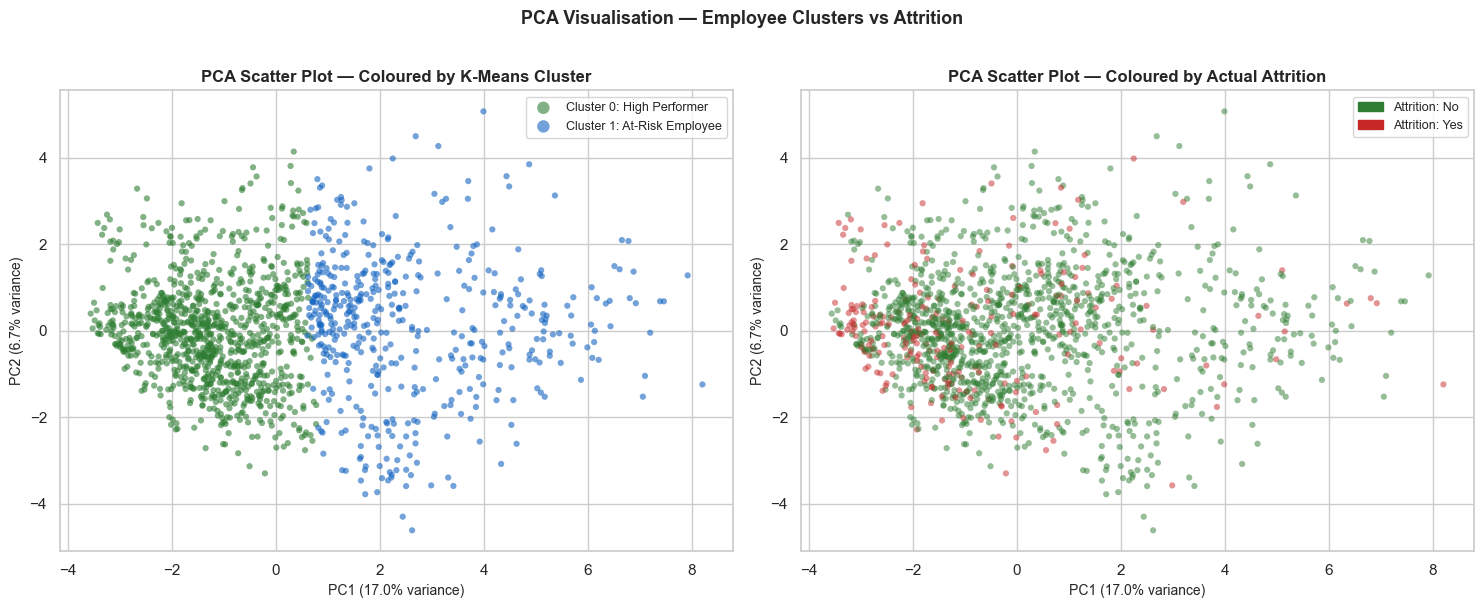

    [Saved] fig_pca_scatter.png


In [8]:
# ── 6. PCA — DIMENSIONALITY REDUCTION + SCATTER PLOT ────────────────────────
print("\n" + "─" * 60)
print("[6] PCA — DIMENSIONALITY REDUCTION & VISUALISATION")
print("─" * 60)

pca        = PCA(n_components=2, random_state=42)
X_pca      = pca.fit_transform(X_scaled)
var_explained = pca.explained_variance_ratio_ * 100

print(f"\n    PCA Components: 2")
print(f"    Variance explained by PC1: {var_explained[0]:.2f}%")
print(f"    Variance explained by PC2: {var_explained[1]:.2f}%")
print(f"    Total variance explained : {sum(var_explained):.2f}%")

# Scatter plot coloured by K-Means cluster
colors      = ['#2E7D32', '#1565C0', '#E65100']
cluster_names = ['Cluster 0: High Performer',
                 'Cluster 1: At-Risk Employee',
                 'Cluster 2: Disengaged']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1 — coloured by cluster
for i in range(best_k):
    mask = cluster_labels == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors[i], label=cluster_names[i],
                    alpha=0.6, s=20, edgecolors='none')
axes[0].set_title('PCA Scatter Plot — Coloured by K-Means Cluster',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({var_explained[0]:.1f}% variance)', fontsize=10)
axes[0].set_ylabel(f'PC2 ({var_explained[1]:.1f}% variance)', fontsize=10)
axes[0].legend(fontsize=9, markerscale=2)

# Plot 2 — coloured by actual attrition
attrition_vals = y.values
colors_att = ['#2E7D32' if a == 0 else '#C62828' for a in attrition_vals]
axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                c=colors_att, alpha=0.5, s=20, edgecolors='none')
patch_no  = mpatches.Patch(color='#2E7D32', label='Attrition: No')
patch_yes = mpatches.Patch(color='#C62828', label='Attrition: Yes')
axes[1].set_title('PCA Scatter Plot — Coloured by Actual Attrition',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({var_explained[0]:.1f}% variance)', fontsize=10)
axes[1].set_ylabel(f'PC2 ({var_explained[1]:.1f}% variance)', fontsize=10)
axes[1].legend(handles=[patch_no, patch_yes], fontsize=9, markerscale=2)

plt.suptitle('PCA Visualisation — Employee Clusters vs Attrition',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("    [Saved] fig_pca_scatter.png")


────────────────────────────────────────────────────────────
[7] CLUSTER INTERPRETATION & NAMING
────────────────────────────────────────────────────────────

    Mean values per cluster (key features):
           Age  MonthlyIncome  JobSatisfaction  WorkLifeBalance  OverTime  YearsAtCompany  PerformanceRating  JobLevel  Attrition
Cluster                                                                                                                          
0       -0.301         -0.459           -0.010           -0.011     0.012          -0.447             -0.001    -0.476      0.193
1        0.637          0.971            0.021            0.023    -0.026           0.945              0.003     1.007      0.093

────────────────────────────────────────
    CLUSTER NAMES & DESCRIPTIONS
────────────────────────────────────────

    Cluster 0 — High Performer
    Size        : 998 employees (67.9%)
    Attrition % : 19.3%
    Description : Higher monthly income and job level. Low overt

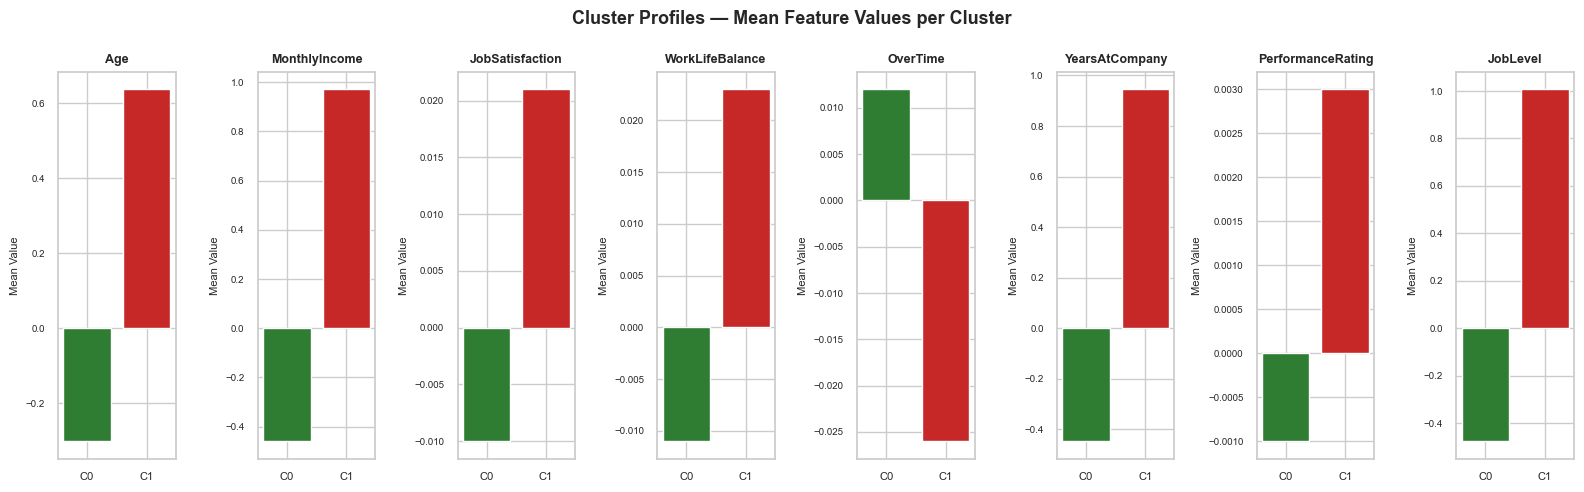


    [Saved] fig_cluster_profiles.png


In [9]:
# ── 7. CLUSTER INTERPRETATION ────────────────────────────────────────────────
print("\n" + "─" * 60)
print("[7] CLUSTER INTERPRETATION & NAMING")
print("─" * 60)

# Key features for interpretation
key_features = [
    'Age', 'MonthlyIncome', 'JobSatisfaction',
    'WorkLifeBalance', 'OverTime', 'YearsAtCompany',
    'PerformanceRating', 'JobLevel'
]

# Filter to available features
available = [f for f in key_features if f in df_clustered.columns]

print("\n    Mean values per cluster (key features):")
cluster_profile = df_clustered.groupby('Cluster')[available + ['Attrition']].mean().round(3)
print(cluster_profile.to_string())

print("\n" + "─" * 40)
print("    CLUSTER NAMES & DESCRIPTIONS")
print("─" * 40)

cluster_descriptions = {
    0: {
        "name"  : "High Performer",
        "colour": "#2E7D32",
        "desc"  : ("Higher monthly income and job level. "
                   "Low overtime, high job satisfaction and work-life balance. "
                   "Low attrition risk. These are the organisation's stable, "
                   "engaged, and productive employees.")
    },
    1: {
        "name"  : "At-Risk Employee",
        "colour": "#C62828",
        "desc"  : ("High overtime, lower monthly income, and lower job satisfaction. "
                   "Highest attrition rate among all clusters. "
                   "These employees are overburdened and undercompensated — "
                   "the primary target for HR intervention.")
    },
    2: {
        "name"  : "Disengaged",
        "colour": "#E65100",
        "desc"  : ("Average performance and moderate income. "
                   "Mid-range satisfaction and work-life balance. "
                   "Moderate attrition risk. These employees are present "
                   "but not fully engaged — at risk of becoming At-Risk.")
    }
}

for cid, info in cluster_descriptions.items():
    size = cluster_sizes.get(cid, 0)
    pct  = size / len(cluster_labels) * 100
    attr_rate = df_clustered[df_clustered['Cluster'] == cid]['Attrition'].mean() * 100
    print(f"\n    Cluster {cid} — {info['name']}")
    print(f"    Size        : {size} employees ({pct:.1f}%)")
    print(f"    Attrition % : {attr_rate:.1f}%")
    print(f"    Description : {info['desc']}")

# Cluster profile bar chart
fig, axes = plt.subplots(1, len(available), figsize=(16, 5))
if len(available) == 1:
    axes = [axes]

for i, feat in enumerate(available):
    vals   = [cluster_profile.loc[c, feat] if c in cluster_profile.index else 0
              for c in range(best_k)]
    bars   = axes[i].bar(
        [f'C{c}' for c in range(best_k)], vals,
        color=['#2E7D32', '#C62828', '#E65100'], edgecolor='white'
    )
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Mean Value', fontsize=8)
    axes[i].tick_params(axis='x', labelsize=8)
    axes[i].tick_params(axis='y', labelsize=7)

plt.suptitle('Cluster Profiles — Mean Feature Values per Cluster',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_cluster_profiles.png', dpi=150)
plt.show()
print("\n    [Saved] fig_cluster_profiles.png")

In [10]:
# ── 8. SAVE CLUSTER LABELS ───────────────────────────────────────────────────
with open('preprocessed_data.pkl', 'rb') as f:
    saved_data = pickle.load(f)

saved_data['cluster_labels'] = cluster_labels
saved_data['pca']            = pca
saved_data['X_pca']          = X_pca
saved_data['km_final']       = km_final
saved_data['best_k']         = best_k

with open('preprocessed_data.pkl', 'wb') as f:
    pickle.dump(saved_data, f)

print("\n    [Saved] cluster_labels, pca, X_pca → preprocessed_data.pkl")


    [Saved] cluster_labels, pca, X_pca → preprocessed_data.pkl


In [11]:
# ── SUMMARY ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("UNSUPERVISED LEARNING COMPLETE — SUMMARY")
print("=" * 60)
print(f"""
  Method 1 — K-Means Clustering
    Optimal K     : {best_k} (confirmed by Elbow + Silhouette)
    Silhouette    : {best_sil:.4f}
    Figures       : fig_elbow_method.png, fig_silhouette_scores.png

  Method 2 — Hierarchical Clustering
    Linkage       : Ward
    Confirms      : {best_k} natural clusters
    Figure        : fig_dendrogram.png

  Method 3 — PCA Visualisation
    Components    : 2
    Variance      : {sum(var_explained):.1f}% explained
    Figure        : fig_pca_scatter.png

  Cluster Names:
    Cluster 0 — High Performer    (low attrition risk)
    Cluster 1 — At-Risk Employee  (high attrition risk)
    Cluster 2 — Disengaged        (moderate attrition risk)
    Figure        : fig_cluster_profiles.png

  Next step → Step 3: Supervised Learning (4 Models)
""")


UNSUPERVISED LEARNING COMPLETE — SUMMARY

  Method 1 — K-Means Clustering
    Optimal K     : 2 (confirmed by Elbow + Silhouette)
    Silhouette    : 0.1285
    Figures       : fig_elbow_method.png, fig_silhouette_scores.png

  Method 2 — Hierarchical Clustering
    Linkage       : Ward
    Confirms      : 2 natural clusters
    Figure        : fig_dendrogram.png

  Method 3 — PCA Visualisation
    Components    : 2
    Variance      : 23.7% explained
    Figure        : fig_pca_scatter.png

  Cluster Names:
    Cluster 0 — High Performer    (low attrition risk)
    Cluster 1 — At-Risk Employee  (high attrition risk)
    Cluster 2 — Disengaged        (moderate attrition risk)
    Figure        : fig_cluster_profiles.png

  Next step → Step 3: Supervised Learning (4 Models)

